In [ ]:
#import Required Packages

In [1]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install dmba

     ---------------------------------------- 11.8/11.8 MB 3.4 MB/s eta 0:00:00
     ---------------------------------------- 47.3/47.3 kB 1.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [10]:
#numpy >> Dataset Processing 
#pandas >> Dataset processing and importing
#scikit learn , statsmodel & dmba >> ML & Statistical models
#matplotlib & seaborn >> charts

In [23]:
from pathlib import Path # to interact with file system.

import numpy as np
import pandas as pd


# for working with data frames (tables).

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as sm
from pandas.plotting import scatter_matrix, parallel_coordinates
import matplotlib.pylab as plt
import seaborn as sns # Making statistical graphs on top of what matplot can do 

import dmba
from dmba import regressionSummary, exhaustive_search
from dmba import backward_elimination, forward_selection, stepwise_selection
from dmba import adjusted_r2_score, AIC_score, BIC_score

%matplotlib inline

# Importing csv data file
# Checking the dimensions(No. of rows and columns) and checking the first, last and sample data

#in pandas rowNo starts with 0

In [27]:
housing_df = pd.read_csv(r"C:/Users/madugula vihas/downloads/BostonHousing.csv")

In [28]:
housing_df.shape

(506, 14)

In [29]:
housing_df.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV,CAT. MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0,0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6,0
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7,1
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4,1
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2,1


In [30]:
housing_df.tail(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV,CAT. MEDV
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4,0
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6,0
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9,0
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0,0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,7.88,11.9,0


In [32]:
housing_df.sample(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV,CAT. MEDV
134,0.97617,0.0,21.89,0,0.624,5.757,98.4,2.3460,4,437,21.2,17.31,15.6,0
198,0.03768,80.0,1.52,0,0.404,7.274,38.3,7.3090,2,329,12.6,6.62,34.6,1
16,1.05393,0.0,8.14,0,0.538,5.935,29.3,4.4986,4,307,21.0,6.58,23.1,0
38,0.17505,0.0,5.96,0,0.499,5.966,30.2,3.8473,5,279,19.2,10.13,24.7,0
19,0.72580,0.0,8.14,0,0.538,5.727,69.5,3.7965,4,307,21.0,11.28,18.2,0


# Data Cleaning - Specifically with Column Names

In [33]:
housing_df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'LSTAT', 'MEDV', 'CAT. MEDV'],
      dtype='object')

In [34]:
housing_df = housing_df.rename(columns = {'CAT. MEDV' : 'CAT_MEDV'} )

In [35]:
housing_df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'LSTAT', 'MEDV', 'CAT_MEDV'],
      dtype='object')

# Knowing Data types of all Columns, Dropping unnecessary columns and creating dummy  Columns for Categorical Variables

In [36]:
housing_df.dtypes

CRIM        float64
ZN          float64
INDUS       float64
CHAS          int64
NOX         float64
RM          float64
AGE         float64
DIS         float64
RAD           int64
TAX           int64
PTRATIO     float64
LSTAT       float64
MEDV        float64
CAT_MEDV      int64
dtype: object

In [ ]:
# Checking the format and Handling missing values with deletion, mean/median imputation or business specific rules

In [38]:
housing_df = housing_df.drop(columns = ['CAT_MEDV'])

In [40]:
housing_df.columns

#checking whether the CAT_MEDV column got deleted

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'LSTAT', 'MEDV'],
      dtype='object')

In [39]:
housing_df.describe() #gives all the statistics summary of Data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


In [ ]:
# Tax, AGE, ZN columns data have hig Std Deviation
# Count is 506 >> No missing Values



# Handling Missing Values

In [ ]:
# No missing Values 

In [ ]:
np.round(housing_df.describe(),decimals=1) #Rounding the number to 1 decimal point

# Visualization Using charts

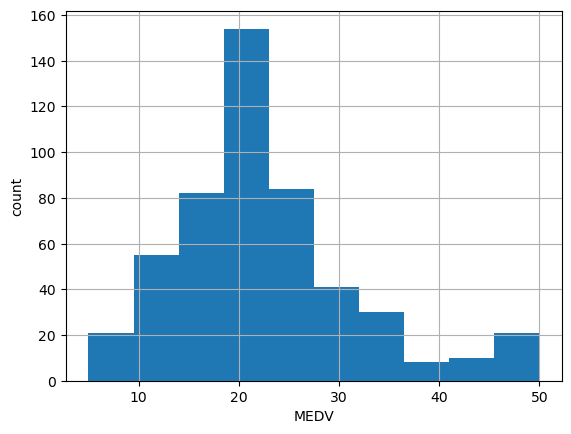

In [41]:
# Histogran for Dependent or Traget or Outcome Variable i.e., MEDV

hist = housing_df['MEDV'].hist()

hist.set_xlabel('MEDV') # Change label Same as Col Name
hist.set_ylabel('count') #No changing

plt.show()

#count on y-axis and MEDV on x-axis >> following Normal Distribution - No need to worry on data points

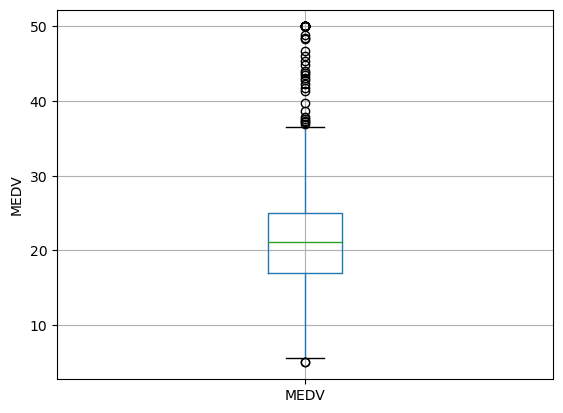

In [43]:
# Box-plot for Dependent Variable

ax = housing_df.boxplot(column = 'MEDV')
ax.set_ylabel('MEDV')

plt.show()


#Data points are almost near to mean and MEDV values >35 Outliars - Still a good data

In [ ]:
# Independent Variables/ Predictors = Rest all 

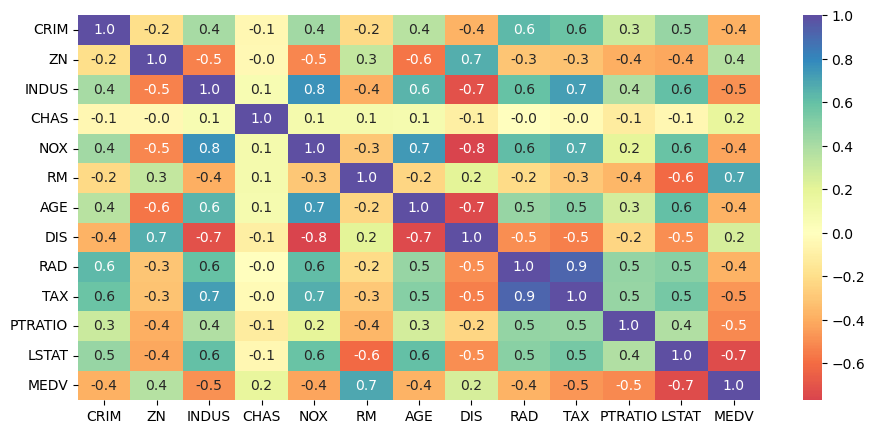

In [45]:
# HeatMap for all numerical variables correlation with Values

corr = housing_df.corr()

fig, ax = plt.subplots()
fig.set_size_inches(11,5)
sns.heatmap(corr, annot=True, fmt=".1f", cmap="Spectral", center=0, ax=ax)

plt.show()

# -ve value >> Negative Correlation and +ve Value >> Positive Correlation

#need to understand &  focus on this code - checking Correlation using seaborn

# Multiple Linear Regression Model

In [71]:
predictors = ['CRIM', 'ZN', 'CHAS', 'NOX', 'RM', 'DIS',  'RAD', 'TAX', 'PTRATIO', 'LSTAT']

outcome = 'MEDV'

In [72]:
X = housing_df[predictors]
y = housing_df[outcome]

In [73]:
train_X,valid_X,train_y,valid_y = train_test_split(X,y,test_size=0.3, random_state=1)

#testing & Validate = 30% of Data and Train = 70%

# got error when use "x" instead of X >> case_sensitive as we use X 

In [74]:
#Check for the model with Less MAE and Good ADJ R-Square. Update columns Below
train_df = train_X[predictors].join(train_y)

formula = outcome + ' ~ ' + ' + '.join(predictors)

housing_lm = sm.ols(formula=formula, data=train_df).fit()

print(housing_lm.summary())

# need to understand this code

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     82.72
Date:                Sun, 17 May 2026   Prob (F-statistic):           3.82e-85
Time:                        15:31:53   Log-Likelihood:                -1063.3
No. Observations:                 354   AIC:                             2149.
Df Residuals:                     343   BIC:                             2191.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     49.4191      6.063      8.150      0.0

In [75]:
# R-sq & Adj R-sq both should be >0.7 & close to each other

#P value should be <0.05

# Insights From Data
# 1 unit increase in Crime Rate will decreases the House Value by 0.115Mn
# 1unit increase in NOx(Pollution level) decreases the House Value by 20Mn
# 1 unit increase in Zn will increase house value by 0.05Mn and so on

In [102]:
MEDV = 49 + X['CRIM'] * (-0.115) + X['ZN'] * (0.05) + X['CHAS'] * (2.57) + X['NOX'] * (-20.98) + X['RM'] * (2.71) + X['DIS'] * (-1.59) + X['RAD'] * (0.28) + X['TAX'] * (-0.01)+ X['PTRATIO'] * (-0.97) + X['LSTAT'] *(-0.57)

In [103]:
#MEDV = 49 + CRIM * (-0.115) + ZN * (0.05) + CHAS * (2.57) + NOX * (-20.98) + RM * ( 2.71) + DIS * (-1.59) + RAD * (0.28) + TAX * (-0.01) + PTRATIO * (-0.97) + LSTAT * (-0.57) 

In [104]:
#X = housing_df[predictors]
#y = housing_df[outcome]

#housing_lm.fit(X,y)

prediction = housing_lm.predict(X)

print(predictions)

0      30.104626
1      24.672268
2      29.680556
3      27.896524
4      26.920023
         ...    
501    22.902296
502    22.267351
503    26.752254
504    25.419136
505    22.368801
Length: 506, dtype: float64


In [87]:
comparision = pd.DataFrame({'Actual MEDV' : y, 'Predicted MEDV' : predictions })

print(comparision.head())

   Actual MEDV  Predicted MEDV
0         24.0       30.104626
1         21.6       24.672268
2         34.7       29.680556
3         33.4       27.896524
4         36.2       26.920023
